In [4]:
import pandas as pd
import numpy as np

In [5]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.shape, test.shape)

(7352, 563) (2947, 563)


In [6]:
motion_train = train.iloc[:, :20]
motion_test = test.iloc[:, :20]

In [7]:
train_mag = motion_train.mean(axis=1)
test_mag = motion_test.mean(axis=1)

threshold = np.percentile(train_mag, 75)

y_train = (train_mag > threshold).astype(int)
y_test = (test_mag > threshold).astype(int)

In [8]:
noise = np.random.rand(len(y_train)) < 0.1
y_train[noise] = 1 - y_train[noise]

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model_scratch = RandomForestClassifier()

model_scratch.fit(motion_train, y_train)

y_pred = model_scratch.predict(motion_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9796403121818799


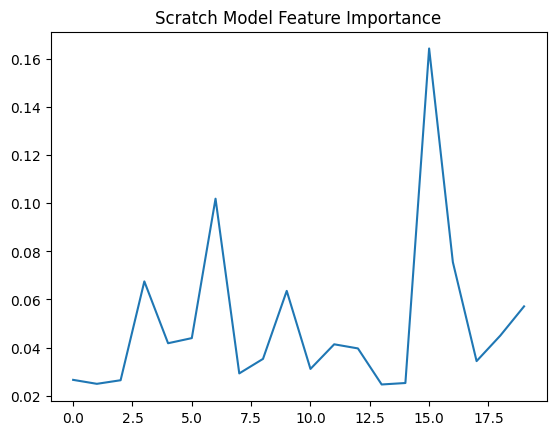

In [10]:
import matplotlib.pyplot as plt

importances = model_scratch.feature_importances_

plt.plot(importances)
plt.title("Scratch Model Feature Importance")
plt.show()

In [11]:
import joblib
joblib.dump(model_scratch, "scratch_model.pkl")

['scratch_model.pkl']